# 🛒 Cafe Item Recommendation System — ML Pipeline
**Model**: Item-Based Collaborative Filtering menggunakan KNN (K-Nearest Neighbors)  
**Dataset**: `bread_basket.csv` — transaksi pembelian di sebuah kafe  
**Tujuan**: Merekomendasikan item kafe berdasarkan item yang sudah ada di keranjang belanja  

---
### Alur Pipeline ML:
1. Problem Definition
2. Data Loading & Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Train / Validation Split
5. Model Training (KNN)
6. Visualisasi Model
7. Evaluasi pada Validation Set
8. Analisis Kelemahan (Weakness Analysis)

In [1]:
# ─── Import Libraries ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import json
from pathlib import Path
from itertools import combinations
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Libraries loaded!')

C:\Users\leona\AppData\Local\Temp\ipykernel_29864\3931848691.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Libraries loaded!


---
## 1. Problem Definition
**Konteks**: Sebuah kafe ingin meningkatkan nilai transaksi dengan merekomendasikan item tambahan kepada pelanggan berdasarkan isi keranjang belanja mereka.

**Pendekatan**: *Item-Based Collaborative Filtering* — mencari item lain yang sering dibeli bersamaan dalam satu transaksi.

**Input** → daftar item yang sudah dipilih pelanggan  
**Output** → top-K item lain yang direkomendasikan (K=4)

**Algoritma**: KNN dengan *cosine similarity* pada item-transaction binary matrix

---
## 2. Data Loading & EDA

In [2]:
BASE_DIR = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_PATH   = BASE_DIR / 'data' / 'bread_basket.csv'
MODEL_PATH  = BASE_DIR / 'models' / 'knn_recommendations.json'
SPLIT_PATH  = BASE_DIR / 'models' / 'knn_split_metadata.json'

# Load raw data
df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip()

print('=== Info Dataset Mentah ===')
print(f'Shape           : {df_raw.shape}')
print(f'Kolom           : {df_raw.columns.tolist()}')
print(f'Transaksi unik  : {df_raw["Transaction"].nunique()}')
print(f'Item unik       : {df_raw["Item"].nunique()}')
print(f'NONE items      : {(df_raw["Item"] == "NONE").sum()}')
df_raw.head(8)

=== Info Dataset Mentah ===
Shape           : (20507, 5)
Kolom           : ['Transaction', 'Item', 'date_time', 'period_day', 'weekday_weekend']
Transaksi unik  : 9465
Item unik       : 94
NONE items      : 0


,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend
5,3,Cookies,30-10-2016 10:07,morning,weekend
6,4,Muffin,30-10-2016 10:08,morning,weekend
7,5,Coffee,30-10-2016 10:13,morning,weekend


In [3]:
# Statistik deskriptif dan missing values
print('=== Missing Values ===')
print(df_raw.isnull().sum())
print()
print('=== Distribusi period_day ===')
print(df_raw['period_day'].value_counts())
print()
print('=== Distribusi weekday_weekend ===')
print(df_raw['weekday_weekend'].value_counts())

=== Missing Values ===
Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
dtype: int64

=== Distribusi period_day ===
period_day
afternoon    11569
morning       8404
evening        520
night           14
Name: count, dtype: int64

=== Distribusi weekday_weekend ===
weekday_weekend
weekday    12807
weekend     7700
Name: count, dtype: int64


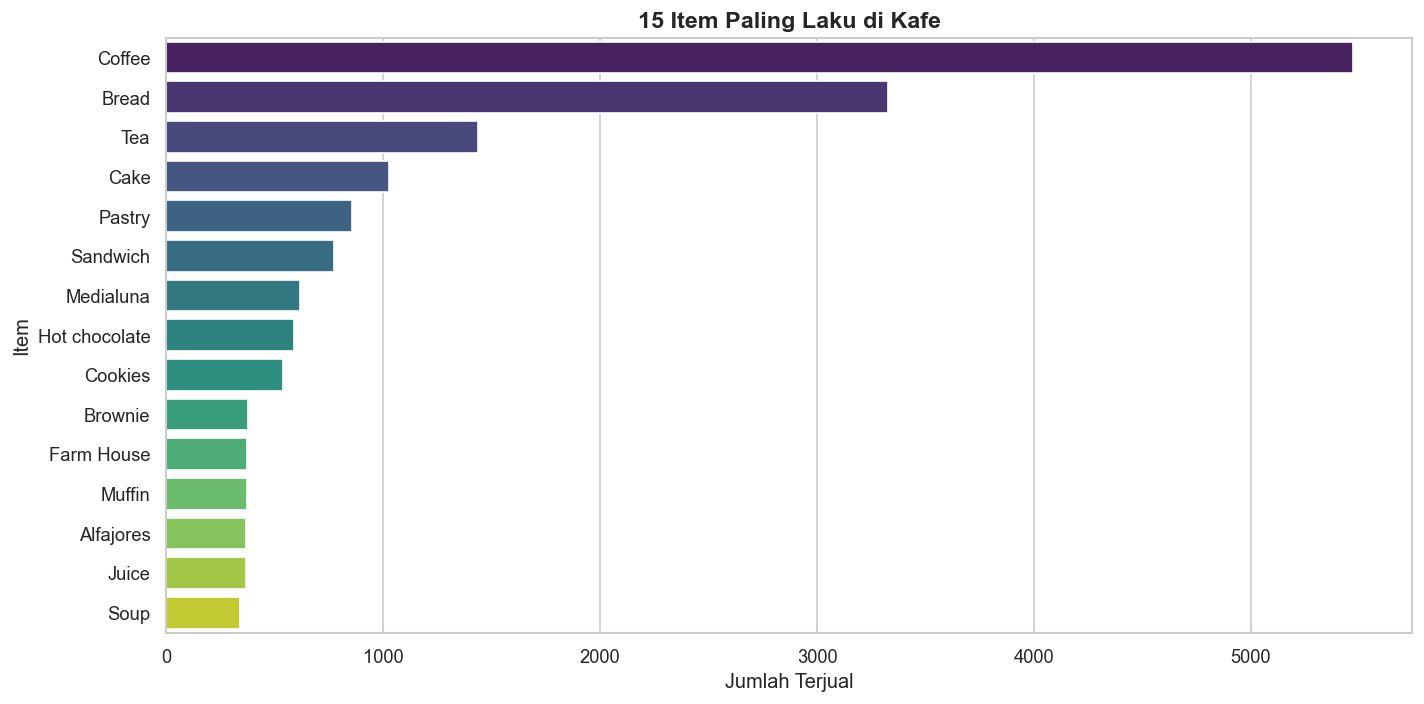

In [4]:
# Hapus baris NONE
df_clean = df_raw[df_raw['Item'] != 'NONE'].copy()

# 15 item paling laku
plt.figure(figsize=(12, 6))
top_items = df_clean['Item'].value_counts().head(15)
sns.barplot(x=top_items.values, y=top_items.index, palette='viridis')
plt.title('15 Item Paling Laku di Kafe', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Terjual')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

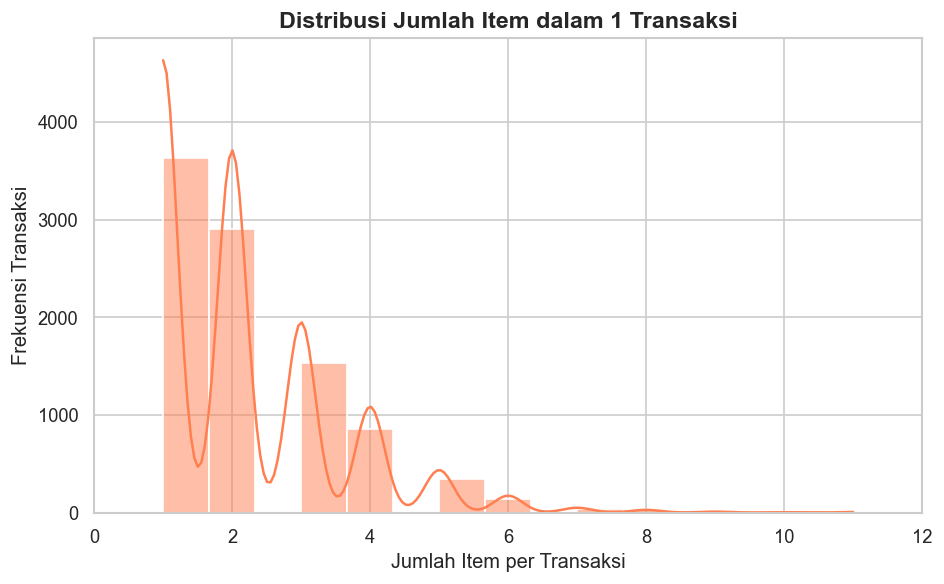

Rata-rata item per transaksi : 2.17
Median item per transaksi    : 2
Transaksi dengan 1 item      : 3631 (38.4%)


In [5]:
# Distribusi jumlah item per transaksi
plt.figure(figsize=(8, 5))
items_per_tx = df_clean.groupby('Transaction')['Item'].count()
sns.histplot(items_per_tx, bins=15, kde=True, color='coral')
plt.title('Distribusi Jumlah Item dalam 1 Transaksi', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Item per Transaksi')
plt.ylabel('Frekuensi Transaksi')
plt.xlim(0, 12)
plt.tight_layout()
plt.show()

print(f'Rata-rata item per transaksi : {items_per_tx.mean():.2f}')
print(f'Median item per transaksi    : {items_per_tx.median():.0f}')
print(f'Transaksi dengan 1 item      : {(items_per_tx == 1).sum()} ({(items_per_tx == 1).mean():.1%})')

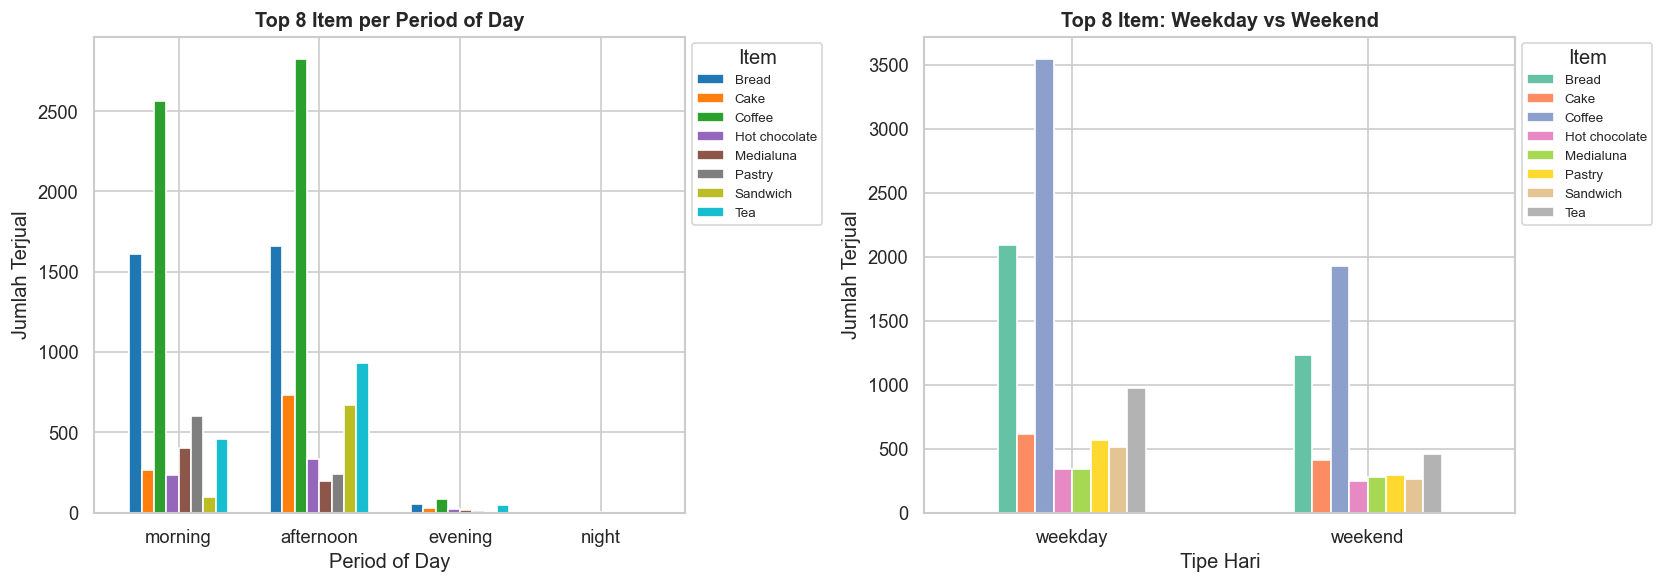

In [6]:
# Analisis Konteks Temporal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

period_order = [p for p in ['morning', 'afternoon', 'evening', 'night'] if p in df_clean['period_day'].unique()]
top8 = df_clean['Item'].value_counts().head(8).index
df_top8 = df_clean[df_clean['Item'].isin(top8)]

pivot_period = df_top8.groupby(['period_day', 'Item']).size().unstack(fill_value=0)
pivot_period = pivot_period.reindex([p for p in period_order if p in pivot_period.index])
pivot_period.plot(kind='bar', ax=axes[0], colormap='tab10', width=0.7)
axes[0].set_title('Top 8 Item per Period of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Period of Day')
axes[0].set_ylabel('Jumlah Terjual')
axes[0].legend(title='Item', bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

pivot_day = df_top8.groupby(['weekday_weekend', 'Item']).size().unstack(fill_value=0)
pivot_day.plot(kind='bar', ax=axes[1], colormap='Set2', width=0.5)
axes[1].set_title('Top 8 Item: Weekday vs Weekend', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tipe Hari')
axes[1].set_ylabel('Jumlah Terjual')
axes[1].legend(title='Item', bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

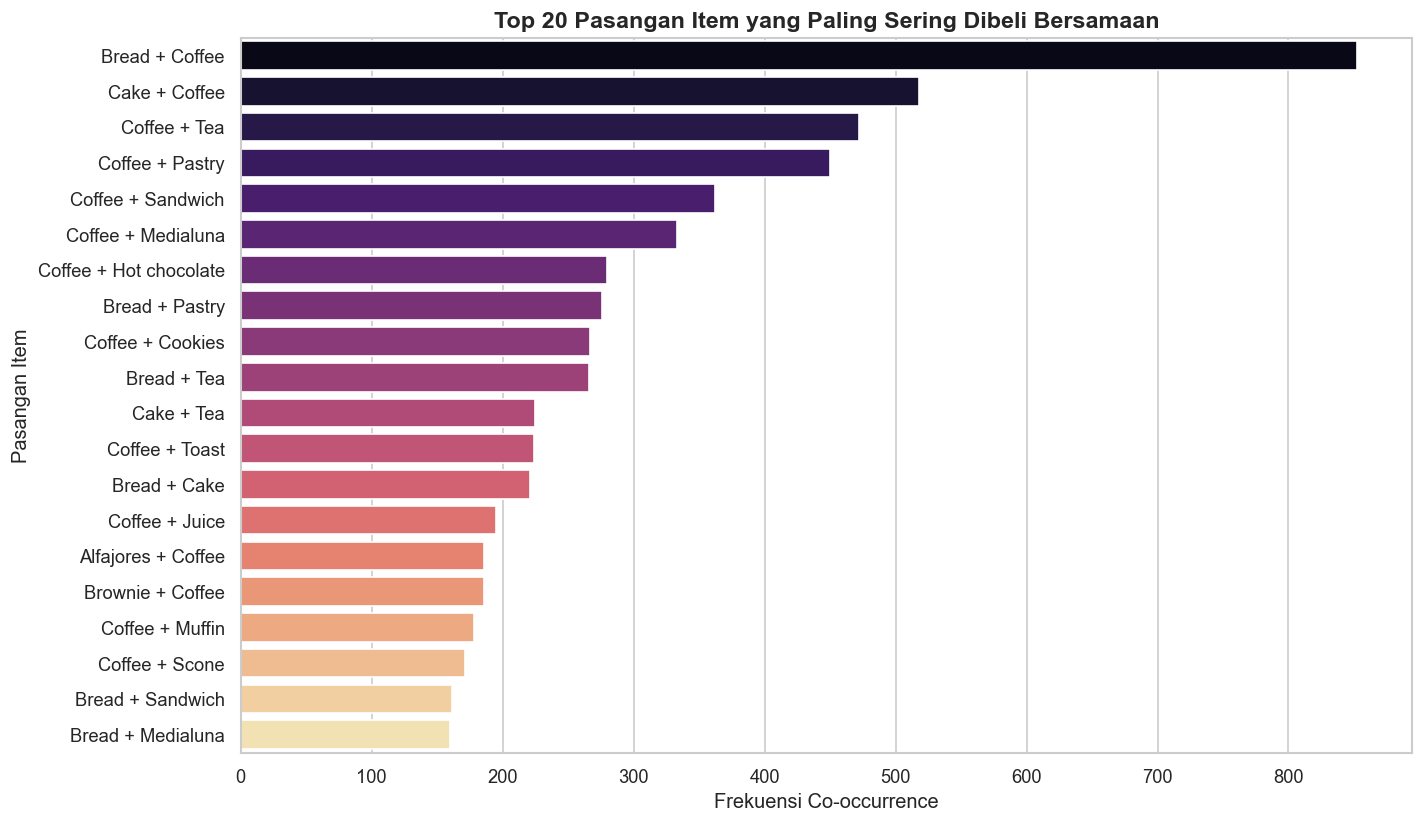


Top 10 Pasangan dengan Support:
            Pair_Label  Count  Support
        Bread + Coffee    852 0.090016
         Cake + Coffee    518 0.054728
          Coffee + Tea    472 0.049868
       Coffee + Pastry    450 0.047544
     Coffee + Sandwich    362 0.038246
    Coffee + Medialuna    333 0.035182
Coffee + Hot chocolate    280 0.029583
        Bread + Pastry    276 0.029160
      Coffee + Cookies    267 0.028209
           Bread + Tea    266 0.028104


In [7]:
# Top 20 pasangan item yang paling sering dibeli bersamaan
transactions_grouped = df_clean.groupby('Transaction')['Item'].apply(lambda x: list(set(x)))
pair_counts = Counter()
for txitems in transactions_grouped:
    if len(txitems) >= 2:
        for pair in combinations(sorted(txitems), 2):
            pair_counts[pair] += 1

top_pairs = pd.DataFrame(pair_counts.most_common(20), columns=['Pair', 'Count'])
top_pairs['Support'] = top_pairs['Count'] / df_clean['Transaction'].nunique()
top_pairs['Pair_Label'] = top_pairs['Pair'].apply(lambda x: f'{x[0]} + {x[1]}')

plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Pair_Label', data=top_pairs, palette='magma')
plt.title('Top 20 Pasangan Item yang Paling Sering Dibeli Bersamaan', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi Co-occurrence')
plt.ylabel('Pasangan Item')
plt.tight_layout()
plt.show()

print('\nTop 10 Pasangan dengan Support:')
print(top_pairs[['Pair_Label', 'Count', 'Support']].head(10).to_string(index=False))

---
## 3. Preprocessing & Feature Engineering

In [8]:
CHOSEN_ITEMS = [
    'Bread', 'Salad', 'Hot chocolate', 'Jam', 'Cookies', 'Muffin', 'Coffee', 'Pastry',
    'Medialuna', 'Tea', 'Tartine', 'Basket', 'Mineral water', 'Fudge', 'Juice',
    'Victorian Sponge', 'Frittata', 'Soup', 'Smoothies', 'Cake', 'Coke', 'Sandwich',
    'Baguette', 'Eggs', 'Brownie', 'Bread Pudding', 'Bacon', 'Toast', 'Scone', 'Crepes'
]

df = df_clean[df_clean['Item'].isin(CHOSEN_ITEMS)].copy()

print(f'Total item di dataset asli : {df_clean["Item"].nunique()}')
print(f'Item yang dipilih          : {len(CHOSEN_ITEMS)}')
print(f'Item yang dibuang          : {df_clean["Item"].nunique() - len(CHOSEN_ITEMS)}')
print(f'Baris setelah filter       : {len(df)}')
print(f'Transaksi unik             : {df["Transaction"].nunique()}')

# Sparsity Analysis
item_tx_full = pd.crosstab(df['Transaction'], df['Item']).clip(upper=1)
total_cells  = item_tx_full.shape[0] * item_tx_full.shape[1]
filled_cells = item_tx_full.values.sum()
sparsity     = 1 - (filled_cells / total_cells)

print(f'\nUkuran Binary Matrix : {item_tx_full.shape[0]} transaksi × {item_tx_full.shape[1]} item')
print(f'Sel terisi           : {int(filled_cells)} dari {total_cells}')
print(f'Sparsity             : {sparsity:.4%}')
print()
print('Interpretasi: Sparsity tinggi → sebagian besar transaksi hanya membeli sedikit item.')
print('Ini umum untuk market basket data. KNN cosine similarity efektif pada data sparse.')

Total item di dataset asli : 94
Item yang dipilih          : 30
Item yang dibuang          : 64
Baris setelah filter       : 17871
Transaksi unik             : 8873

Ukuran Binary Matrix : 8873 transaksi × 30 item
Sel terisi           : 16293 dari 266190
Sparsity             : 93.8792%

Interpretasi: Sparsity tinggi → sebagian besar transaksi hanya membeli sedikit item.
Ini umum untuk market basket data. KNN cosine similarity efektif pada data sparse.


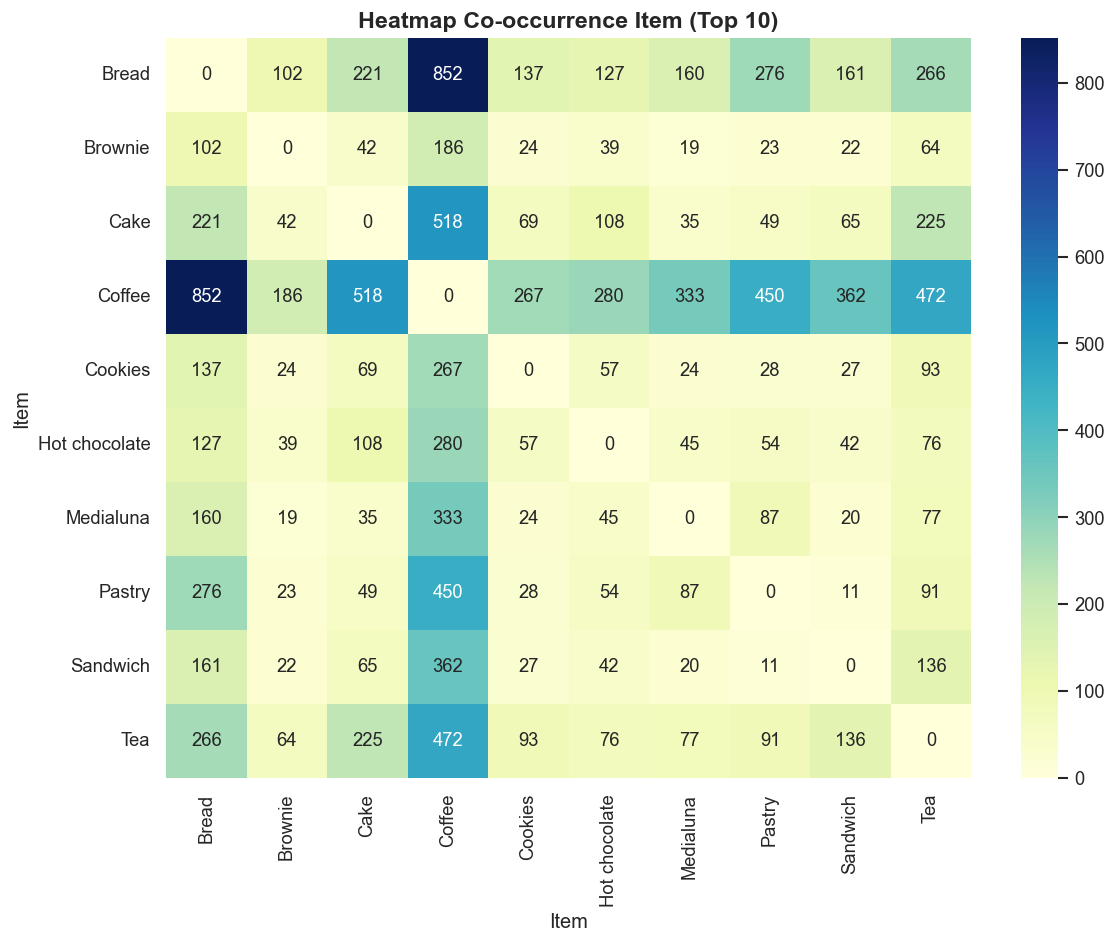

In [9]:
# Heatmap Co-occurrence (top 10 item)
top_10_items = df['Item'].value_counts().head(10).index
df_top10 = df[df['Item'].isin(top_10_items)]
item_tx_matrix_top10 = pd.crosstab(df_top10['Item'], df_top10['Transaction']).clip(upper=1)
co_occurrence = item_tx_matrix_top10.dot(item_tx_matrix_top10.T)
np.fill_diagonal(co_occurrence.values, 0)

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap Co-occurrence Item (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Item')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

---
## 4. Train / Validation Split
Split dilakukan **berdasarkan Transaction ID** (bukan baris/item), sehingga tidak ada data leakage — semua baris dari satu transaksi masuk ke satu set yang sama.

In [10]:
VALIDATION_SIZE = 0.2
RANDOM_STATE    = 42

# Load split metadata yang sudah disimpan oleh train_model.py
with open(MODEL_PATH, 'r', encoding='utf-8') as f:
    rekomendasi_model = json.load(f)

with open(SPLIT_PATH, 'r', encoding='utf-8') as f:
    split_metadata = json.load(f)

validation_ids = set(split_metadata['validation_transaction_ids'])
train_df       = df[~df['Transaction'].isin(validation_ids)].copy()
validation_df  = df[df['Transaction'].isin(validation_ids)].copy()

print('=== Train / Validation Split ===')
print(f'Total transaksi          : {df["Transaction"].nunique()}')
print(f'Train transaksi          : {train_df["Transaction"].nunique()} ({train_df["Transaction"].nunique()/df["Transaction"].nunique():.0%})')
print(f'Validation transaksi     : {validation_df["Transaction"].nunique()} ({validation_df["Transaction"].nunique()/df["Transaction"].nunique():.0%})')
print(f'Random state             : {split_metadata["random_state"]}')
print()
print('⚠️  Split ini KONSISTEN dengan src/train_model.py karena menggunakan metadata yang sama.')
print('   Tidak ada data leakage — validation set tidak pernah disentuh saat training.')

=== Train / Validation Split ===
Total transaksi          : 8873
Train transaksi          : 7098 (80%)
Validation transaksi     : 1775 (20%)
Random state             : 42

⚠️  Split ini KONSISTEN dengan src/train_model.py karena menggunakan metadata yang sama.
   Tidak ada data leakage — validation set tidak pernah disentuh saat training.


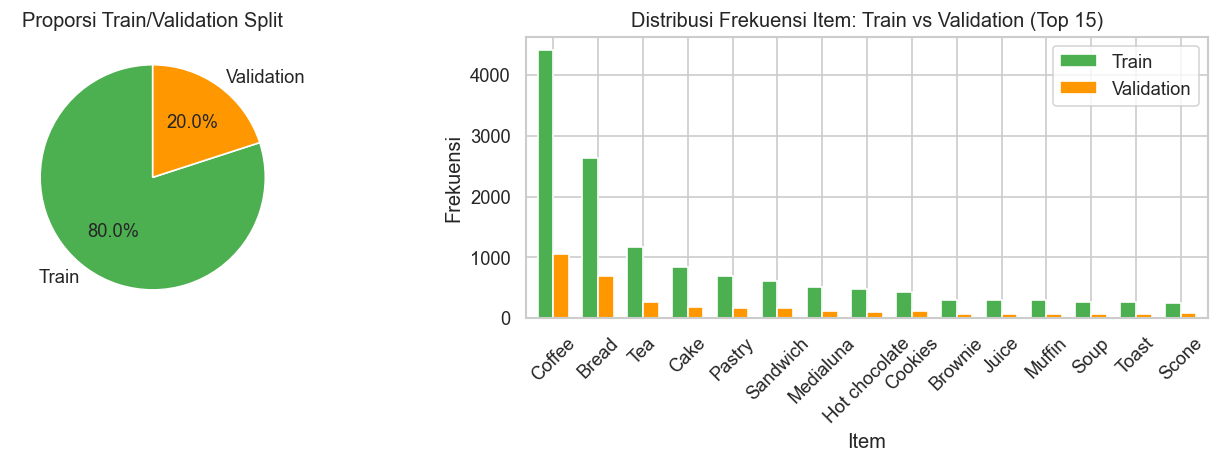

In [11]:
# Visualisasi proporsi split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
train_n = train_df['Transaction'].nunique()
val_n   = validation_df['Transaction'].nunique()
axes[0].pie([train_n, val_n], labels=['Train', 'Validation'],
            autopct='%1.1f%%', colors=['#4CAF50', '#FF9800'], startangle=90)
axes[0].set_title('Proporsi Train/Validation Split')

# Item frequency: train vs validation
train_item_freq = train_df['Item'].value_counts()
val_item_freq   = validation_df['Item'].value_counts()
compare_df = pd.DataFrame({'Train': train_item_freq, 'Validation': val_item_freq}).fillna(0)
compare_df = compare_df.sort_values('Train', ascending=False).head(15)
compare_df.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#FF9800'], width=0.7)
axes[1].set_title('Distribusi Frekuensi Item: Train vs Validation (Top 15)')
axes[1].set_xlabel('Item')
axes[1].set_ylabel('Frekuensi')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 5. Model Training — KNN Item-Based
Model dilatih hanya menggunakan **training data**. Feature space: binary item-transaction matrix.

**Similarity metric**: Cosine Similarity — mengukur sudut antara dua vektor item, tidak terpengaruh frekuensi absolut.  
**n_neighbors = 5** (index 0 = item itu sendiri, jadi effective K = 4)

In [12]:
# Rebuild item-transaction matrix dari training data
item_transaction_matrix = pd.crosstab(train_df['Item'], train_df['Transaction']).clip(upper=1)

print('=== Item-Transaction Binary Matrix (Training) ===')
print(f'Shape  : {item_transaction_matrix.shape[0]} item × {item_transaction_matrix.shape[1]} transaksi')
print(f'Density: {item_transaction_matrix.values.mean():.4%} sel bernilai 1')
print()
print('Contoh (5 item pertama, 8 transaksi pertama):')
item_transaction_matrix.iloc[:5, :8]

=== Item-Transaction Binary Matrix (Training) ===
Shape  : 30 item × 7098 transaksi
Density: 6.1454% sel bernilai 1

Contoh (5 item pertama, 8 transaksi pertama):


Transaction,3,4,5,6,7,8,9,11
Item,,,,,,,,
Bacon,0,0,0,0,0,0,0,0
Baguette,0,0,0,0,0,0,0,0
Basket,0,0,0,0,0,0,0,0
Bread,0,0,1,0,0,1,1,1
Bread Pudding,0,0,0,0,0,0,0,0


In [13]:
# Train KNN model
K_NEIGHBORS = 5  # index 0 = item itu sendiri → effective top-4 recommendation
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=K_NEIGHBORS)
knn.fit(item_transaction_matrix.values)

print(f'Model KNN terlatih: {K_NEIGHBORS} neighbors, cosine similarity')
print(f'Total item dalam model: {len(item_transaction_matrix.index)}')
print()
print('Model ini sudah tersimpan oleh src/train_model.py sebagai:')
print(f'  {MODEL_PATH}')
print()
print('Format JSON yang disimpan (score-based):')
first_item = list(rekomendasi_model.keys())[0]
print(f'  "{first_item}": {rekomendasi_model[first_item]}')

Model KNN terlatih: 5 neighbors, cosine similarity
Total item dalam model: 30

Model ini sudah tersimpan oleh src/train_model.py sebagai:
  C:\Users\leona\OneDrive\Documents\SoftDev Projects\Machine Learning AOL Project\backend\models\knn_recommendations.json

Format JSON yang disimpan (score-based):
  "Bacon": [['Juice', 0.057544], ['Coffee', 0.01657], ['Muffin', 0.0], ['Mineral water', 0.0]]


---
## 6. Visualisasi Model KNN

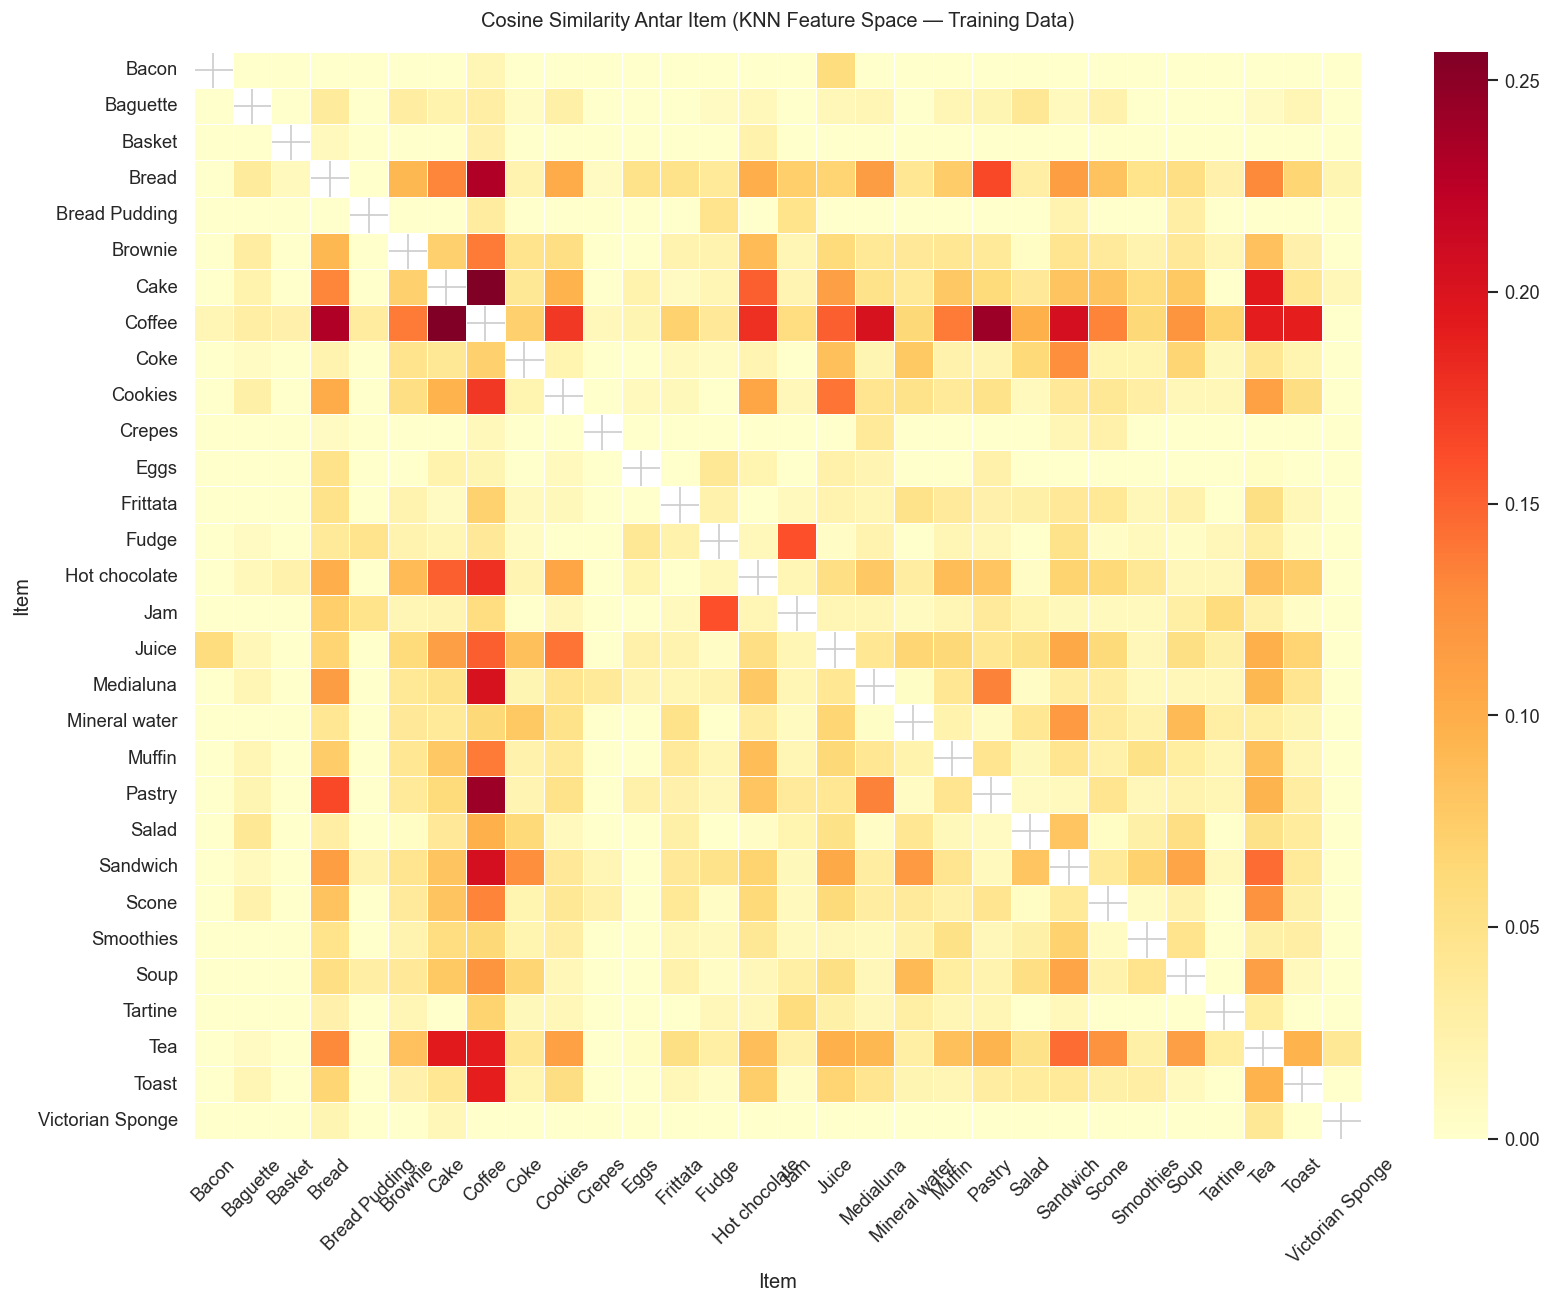

In [14]:
# Heatmap Cosine Similarity Antar Item (dari training data)
cos_sim     = cosine_similarity(item_transaction_matrix.values)
cos_sim_df  = pd.DataFrame(cos_sim,
                            index=item_transaction_matrix.index,
                            columns=item_transaction_matrix.index)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.eye(len(cos_sim_df), dtype=bool)
sns.heatmap(cos_sim_df, mask=mask, annot=False, cmap='YlOrRd',
            linewidths=0.3, ax=ax, vmin=0, vmax=cos_sim_df.values[~mask].max())
ax.set_title('Cosine Similarity Antar Item (KNN Feature Space — Training Data)', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

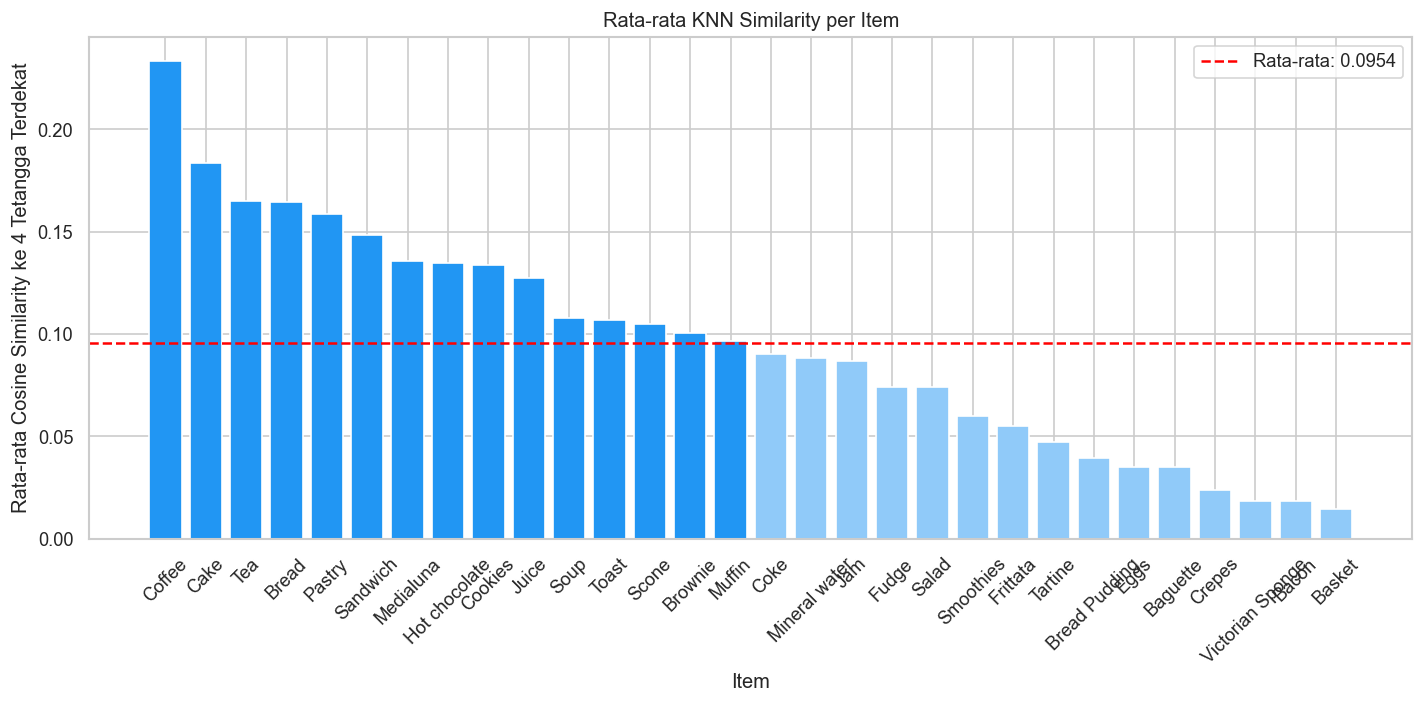

In [15]:
# Rata-rata similarity setiap item ke 4 tetangganya
items = item_transaction_matrix.index.tolist()
distance_records = []
for i, item in enumerate(items):
    distances, indices = knn.kneighbors(
        item_transaction_matrix.iloc[i, :].values.reshape(1, -1)
    )
    for rank, (d, idx) in enumerate(zip(distances.flatten()[1:], indices.flatten()[1:]), 1):
        distance_records.append({
            'Source': item, 'Neighbor': items[idx],
            'Rank': rank, 'Distance': round(d, 4), 'Similarity': round(1 - d, 4)
        })

dist_df  = pd.DataFrame(distance_records)
avg_sim  = dist_df.groupby('Source')['Similarity'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2196F3' if s > avg_sim.mean() else '#90CAF9' for s in avg_sim.values]
bars = ax.bar(avg_sim.index, avg_sim.values, color=colors, edgecolor='white')
ax.axhline(avg_sim.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Rata-rata: {avg_sim.mean():.4f}')
ax.set_xlabel('Item')
ax.set_ylabel('Rata-rata Cosine Similarity ke 4 Tetangga Terdekat')
ax.set_title('Rata-rata KNN Similarity per Item')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

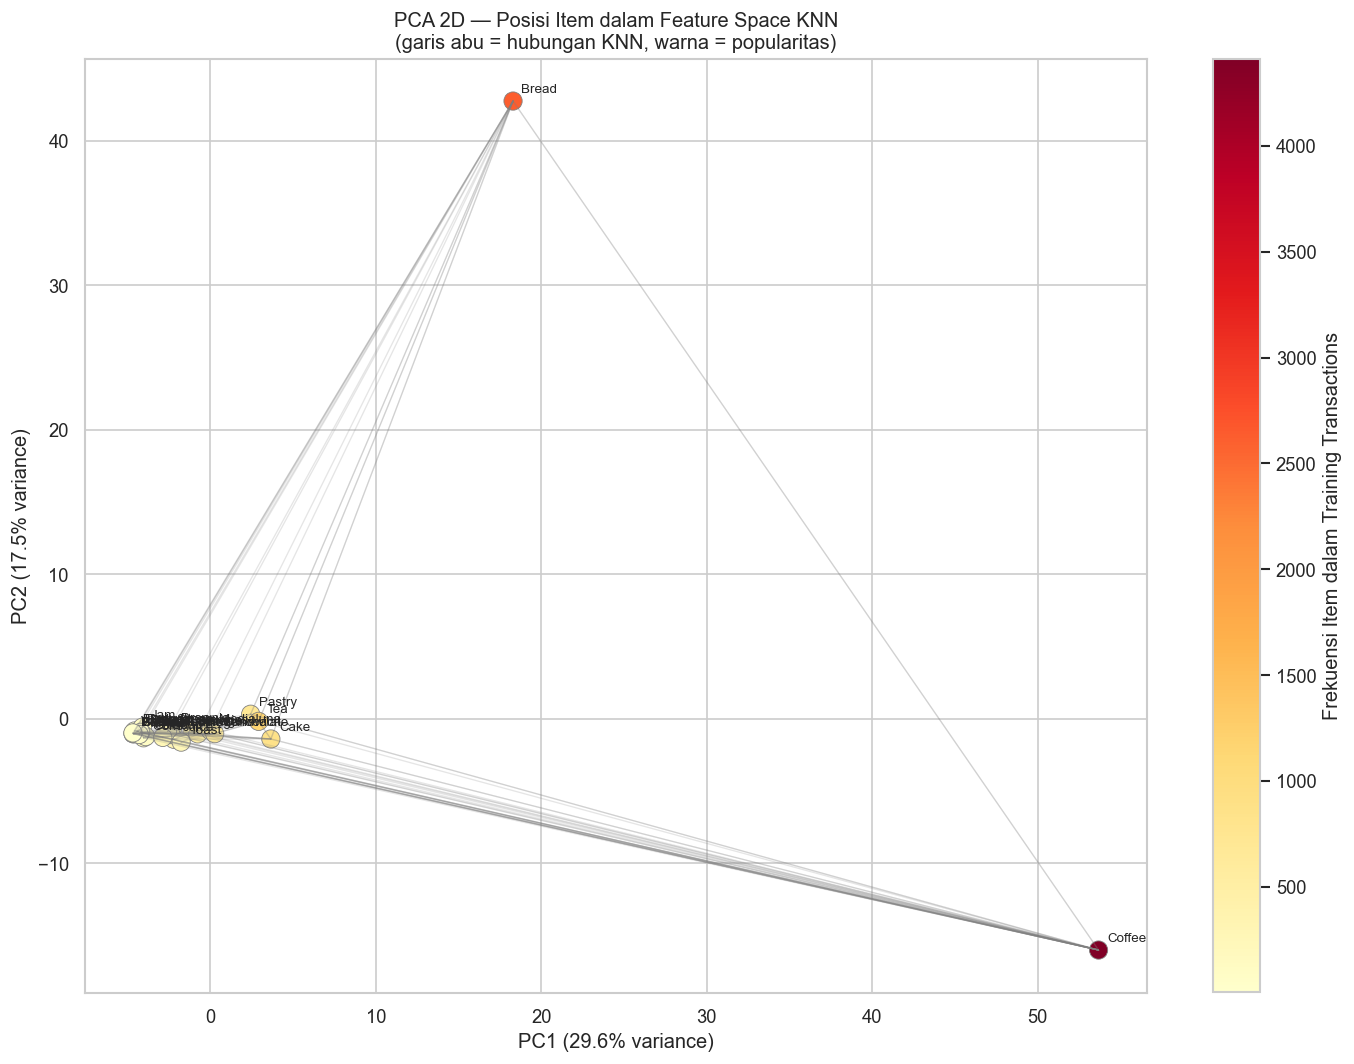

Total variance explained oleh 2 komponen: 47.1%


In [16]:
# Visualisasi PCA 2D — posisi item dalam feature space
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(item_transaction_matrix.values)
item_freq = train_df['Item'].value_counts()

fig, ax = plt.subplots(figsize=(12, 9))
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=[item_freq.get(item, 0) for item in items],
    cmap='YlOrRd', s=120, edgecolors='gray', linewidths=0.5
)
for i, item in enumerate(items):
    ax.annotate(item, (coords[i, 0], coords[i, 1]),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

# Gambar garis ke 4 tetangga terdekat
for i, item in enumerate(items):
    _, idxs = knn.kneighbors(item_transaction_matrix.iloc[i, :].values.reshape(1, -1))
    for idx in idxs.flatten()[1:]:
        ax.plot([coords[i, 0], coords[idx, 0]], [coords[i, 1], coords[idx, 1]],
                'gray', alpha=0.2, linewidth=0.8)

plt.colorbar(scatter, ax=ax, label='Frekuensi Item dalam Training Transactions')
ax.set_title('PCA 2D — Posisi Item dalam Feature Space KNN\n(garis abu = hubungan KNN, warna = popularitas)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

print(f'Total variance explained oleh 2 komponen: {pca.explained_variance_ratio_.sum():.1%}')

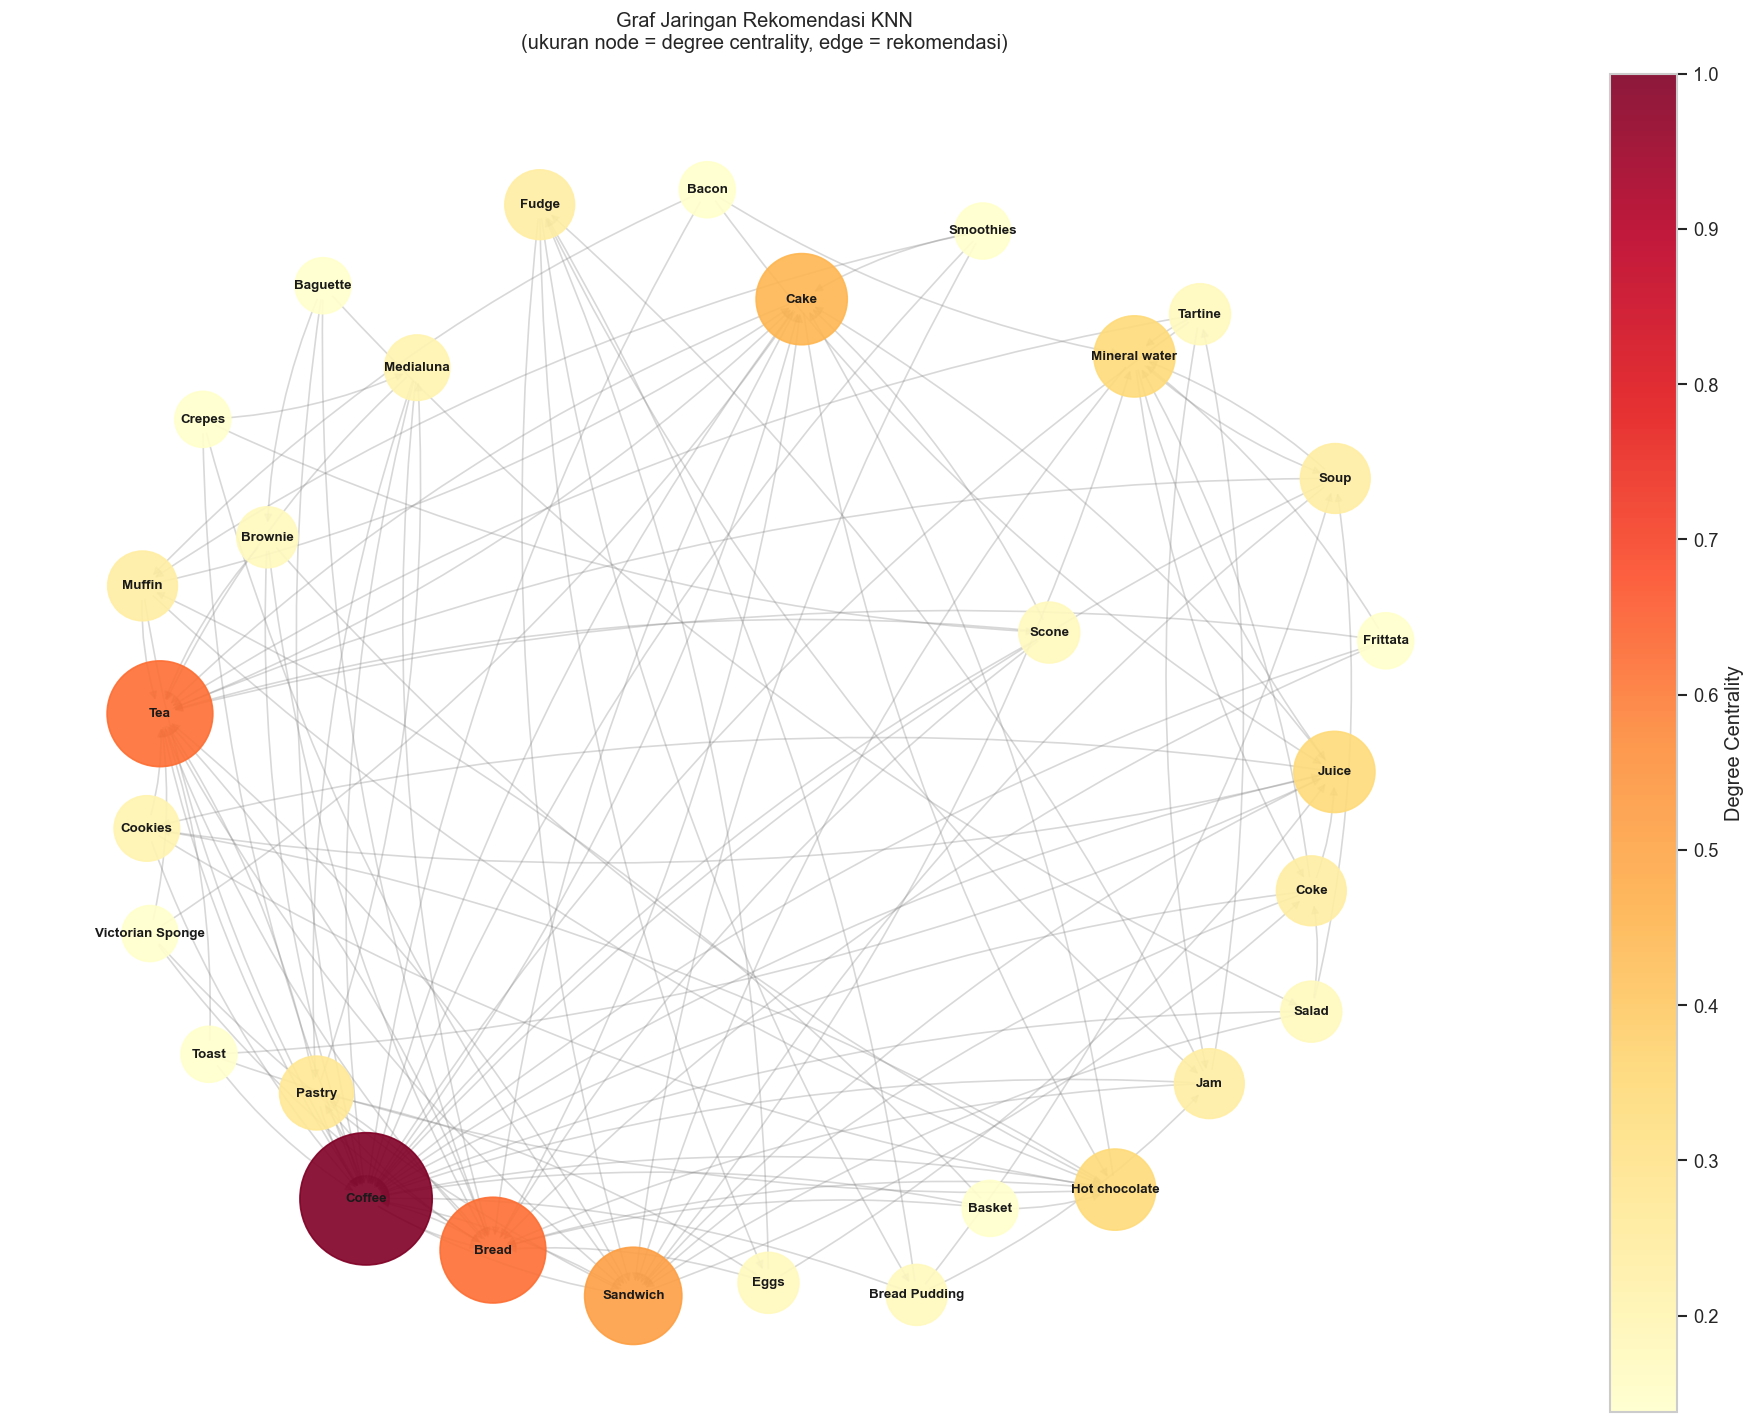

In [17]:
# Graf Jaringan Rekomendasi KNN
G = nx.DiGraph()
for source, neighbors_scores in rekomendasi_model.items():
    for entry in neighbors_scores:
        neighbor, score = entry[0], entry[1]
        G.add_edge(source, neighbor, weight=score)

degree_centrality = nx.degree_centrality(G)
node_sizes  = [degree_centrality[n] * 6000 + 300 for n in G.nodes()]
node_colors = [degree_centrality[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42, k=1.5)
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                                node_color=node_colors, cmap=plt.cm.YlOrRd, ax=ax, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, arrows=True,
                       arrowsize=10, edge_color='gray', connectionstyle='arc3,rad=0.1')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')
plt.colorbar(nodes, ax=ax, label='Degree Centrality')
ax.set_title('Graf Jaringan Rekomendasi KNN\n(ukuran node = degree centrality, edge = rekomendasi)', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 7. Evaluasi Model pada Held-Out Validation Set

**Metrik yang digunakan:**
- **Hit Ratio@K** → Persentase transaksi di mana target item ada di top-K prediksi
- **Precision@K** → Proporsi prediksi yang benar dari K prediksi
- **Recall@K** → Proporsi ground truth yang berhasil ditemukan dalam K prediksi

**Strategi evaluasi:**
- *Target item* = item terakhir dalam urutan transaksi (sebagai proxy ground truth)
- *Input items* = semua item sebelumnya dalam transaksi
- Hanya transaksi dengan ≥ 2 item yang dapat dievaluasi

In [25]:
def deduplicate_preserving_order(items):
    return list(dict.fromkeys(items))

transaksi_dict  = validation_df.groupby('Transaction')['Item'].apply(
    lambda x: deduplicate_preserving_order(x.tolist())
).to_dict()
transaksi_valid = {k: v for k, v in transaksi_dict.items() if len(v) >= 2}

hits             = 0
total_precision  = 0
total_recall     = 0
total_eval       = 0
K                = 4
per_item_hit     = {item: {'hit': 0, 'total': 0} for item in CHOSEN_ITEMS}

for tx_id, items in transaksi_valid.items():
    target_item  = items[-1]
    input_items  = items[:-1]

    # Score-weighted aggregation
    score_map: dict = {}
    for item in input_items:
        if item in rekomendasi_model:
            for entry in rekomendasi_model[item]:
                neighbor, score = entry[0], entry[1]
                if neighbor not in input_items:
                    score_map[neighbor] = score_map.get(neighbor, 0.0) + score

    top_k_prediksi = sorted(score_map, key=lambda x: score_map[x], reverse=True)[:K]

    if not top_k_prediksi:
        continue

    total_eval += 1
    benar       = 1 if target_item in top_k_prediksi else 0

    if target_item in CHOSEN_ITEMS:
        per_item_hit[target_item]['total'] += 1
        per_item_hit[target_item]['hit']   += benar

    hits            += benar
    total_precision += benar / len(top_k_prediksi)
    total_recall    += benar

hit_ratio = (hits / total_eval) * 100
precision = (total_precision / total_eval) * 100
recall    = (total_recall / total_eval) * 100

print(f'Validation transactions dievaluasi : {total_eval}')
print(f'Hit Ratio@{K}                       : {hit_ratio:.2f}%')
print(f'Precision@{K}                       : {precision:.2f}%')
print(f'Recall@{K}                          : {recall:.2f}%')
print()
print(f'Theoretical max Precision@{K}       : {100/K:.2f}%  (satu target = 1/{K} hit)')
print(f'Note: HR@K = Recall@K karena hanya ada 1 ground truth per transaksi.')

Validation transactions dievaluasi : 944
Hit Ratio@4                       : 54.34%
Precision@4                       : 13.61%
Recall@4                          : 54.34%

Theoretical max Precision@4       : 25.00%  (satu target = 1/4 hit)
Note: HR@K = Recall@K karena hanya ada 1 ground truth per transaksi.


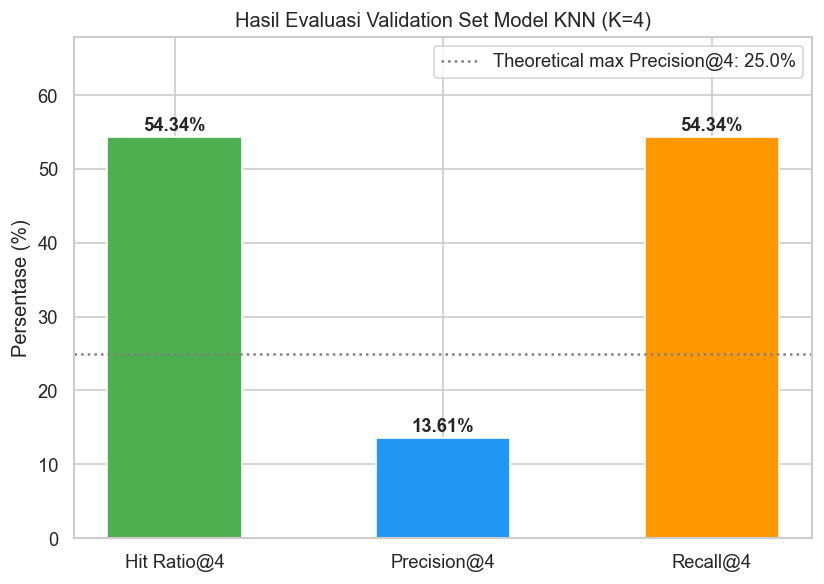

In [19]:
# Visualisasi metrik evaluasi
metrics = {'Hit Ratio@4': hit_ratio, 'Precision@4': precision, 'Recall@4': recall}
colors  = ['#4CAF50', '#2196F3', '#FF9800']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(metrics.keys(), metrics.values(), color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

ax.axhline(100 / K, color='gray', linestyle=':', linewidth=1.5,
           label=f'Theoretical max Precision@{K}: {100/K:.1f}%')
ax.set_ylim(0, max(metrics.values()) * 1.25)
ax.set_ylabel('Persentase (%)')
ax.set_title(f'Hasil Evaluasi Validation Set Model KNN (K={K})')
ax.legend()
plt.tight_layout()
plt.show()

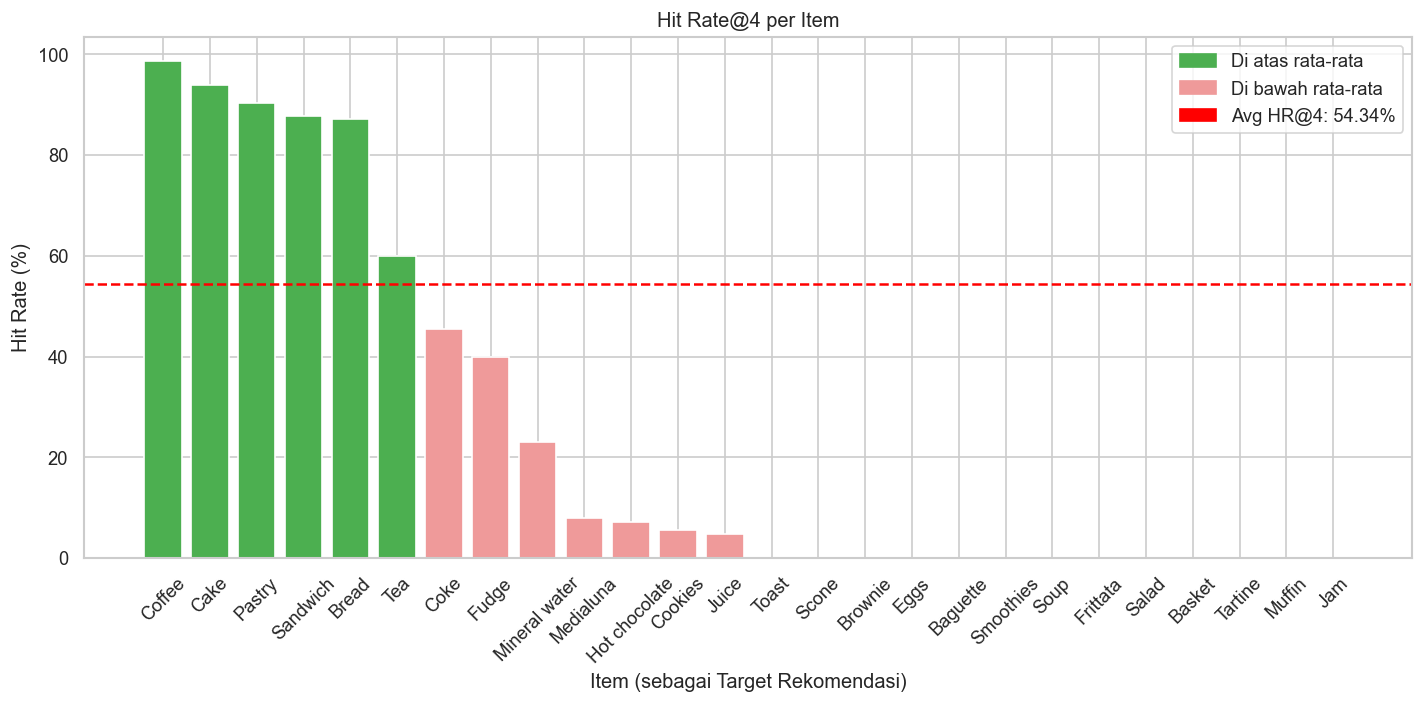

         Item  HitRate%  Evaluasi
       Coffee      98.6       142
         Cake      94.0        83
       Pastry      90.4        83
     Sandwich      87.7        57
        Bread      87.1       132
          Tea      60.0        55
         Coke      45.5        11
        Fudge      40.0        10
Mineral water      23.1        13
    Medialuna       8.0        50
Hot chocolate       7.1        28
      Cookies       5.7        53
        Juice       4.8        21
        Toast       0.0        36
        Scone       0.0        38
      Brownie       0.0        33
         Eggs       0.0         2
     Baguette       0.0        11
    Smoothies       0.0         2
         Soup       0.0        22
     Frittata       0.0         7
        Salad       0.0        10
       Basket       0.0         1
      Tartine       0.0         2
       Muffin       0.0        33
          Jam       0.0         9


In [20]:
# Hit Rate per item
item_hit_rates  = {
    item: (v['hit'] / v['total'] * 100) if v['total'] > 0 else 0
    for item, v in per_item_hit.items()
}
item_hit_series   = pd.Series(item_hit_rates).sort_values(ascending=False)
item_total_series = pd.Series({item: v['total'] for item, v in per_item_hit.items()})
item_hit_series   = item_hit_series[item_total_series > 0]

fig, ax = plt.subplots(figsize=(12, 6))
palette = ['#4CAF50' if v >= hit_ratio else '#EF9A9A' for v in item_hit_series.values]
ax.bar(item_hit_series.index, item_hit_series.values, color=palette, edgecolor='white')
ax.axhline(hit_ratio, color='red', linestyle='--', linewidth=1.5)

green_patch = mpatches.Patch(color='#4CAF50', label='Di atas rata-rata')
red_patch   = mpatches.Patch(color='#EF9A9A', label='Di bawah rata-rata')
avg_patch   = mpatches.Patch(color='red', label=f'Avg HR@4: {hit_ratio:.2f}%')
ax.legend(handles=[green_patch, red_patch, avg_patch])
ax.set_xlabel('Item (sebagai Target Rekomendasi)')
ax.set_ylabel('Hit Rate (%)')
ax.set_title('Hit Rate@4 per Item')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Tabel ringkasan
summary_df = pd.DataFrame({
    'Item'      : item_hit_series.index,
    'HitRate%'  : item_hit_series.values.round(1),
    'Evaluasi'  : [item_total_series[i] for i in item_hit_series.index]
}).reset_index(drop=True)
print(summary_df.to_string(index=False))

---
## 8. Analisis Kelemahan (Weakness Analysis)

Meskipun model sudah berfungsi dengan baik sebagai rekomendasi dasar, terdapat beberapa kelemahan fundamental yang perlu dipahami:

### Kelemahan 1: Ceiling Metrik Evaluasi (Single-Target)

Model ini dievaluasi dengan **satu target item per transaksi** (item terakhir). Konsekuensinya:

$$\text{Precision@K}_{\text{max}} = \frac{1}{K} = \frac{1}{4} = 25\%$$

Artinya, **tidak peduli seberapa sempurna model**, Precision@4 tidak bisa melebihi 25%. Ini bukan kelemahan model, tapi batasan cara evaluasi yang digunakan.

### Kelemahan 2: Target Item yang Noise (Last-Item Heuristic)

Dalam market basket data, **urutan item dalam satu transaksi tidak bermakna** secara semantik — pelanggan bisa memesan "Cake" sebelum atau sesudah "Coffee" tanpa perbedaan signifikan. Menggunakan item terakhir sebagai ground truth memperkenalkan noise yang signifikan.

**Dampak**: Bahkan model yang sempurna merekomendasikan item-item yang relevan, tetapi "item terakhir" yang dipilih sebagai target bisa saja item yang tidak berhubungan sama sekali.

In [21]:
# Demonstrasi noise: ambil 5 transaksi acak dan tunjukkan bahwa target = item terakhir adalah arbitrer
import random
random.seed(42)
sample_ids = random.sample(list(transaksi_valid.keys()), 5)

print('=== Contoh: Target Item Arbitrer (Last-Item Heuristic) ===')
print(f'{"Tx ID":<12} {"Input Items":<50} {"Target (last)":<20}')
print('-' * 85)
for tx_id in sample_ids:
    items_list = transaksi_valid[tx_id]
    print(f'{str(tx_id):<12} {str(items_list[:-1]):<50} {items_list[-1]:<20}')

print()
print('Catatan: Urutan item dalam data mencerminkan urutan DATABASE, bukan urutan pembelian yang sebenarnya.')

=== Contoh: Target Item Arbitrer (Last-Item Heuristic) ===
Tx ID        Input Items                                        Target (last)       
-------------------------------------------------------------------------------------
6885         ['Coffee', 'Tea', 'Medialuna', 'Brownie']          Juice               
1187         ['Bread', 'Brownie']                               Muffin              
241          ['Jam']                                            Tea                 
7846         ['Cake']                                           Coffee              
3229         ['Bread']                                          Toast               

Catatan: Urutan item dalam data mencerminkan urutan DATABASE, bukan urutan pembelian yang sebenarnya.


### Kelemahan 3: Filter 30 Item Menghilangkan Konteks

Dataset asli memiliki **94 item unik**. Setelah filter, hanya 30 item yang digunakan, artinya **~68% item diabaikan**. Ini mengakibatkan:

1. Banyak transaksi yang awalnya memiliki 3-4 item menjadi hanya 1-2 item setelah filter
2. Sinyal co-occurrence menjadi lebih lemah karena konteks hilang
3. Pelanggan yang membeli item di luar 30 ini tidak mendapat rekomendasi yang akurat

In [22]:
# Analisis: berapa banyak transaksi yang kehilangan item setelah filter?
orig_tx_items = df_clean.groupby('Transaction')['Item'].count()
filt_tx_items = df.groupby('Transaction')['Item'].count()

# Transaksi yang ada di clean tapi tidak ada di filtered (seluruh item tidak masuk CHOSEN_ITEMS)
missing_tx = set(df_clean['Transaction'].unique()) - set(df['Transaction'].unique())

# Transaksi yang kehilangan setidaknya 1 item
common_tx = set(orig_tx_items.index) & set(filt_tx_items.index)
lost_context = sum(
    orig_tx_items[tx] - filt_tx_items[tx]
    for tx in common_tx
    if orig_tx_items[tx] > filt_tx_items[tx]
)
total_items_orig = orig_tx_items.sum()

print(f'Total transaksi asli (setelah hapus NONE): {len(orig_tx_items)}')
print(f'Transaksi setelah filter 30 item         : {len(filt_tx_items)}')
print(f'Transaksi hilang sepenuhnya              : {len(missing_tx)} ({len(missing_tx)/len(orig_tx_items):.1%})')
print(f'Total item asli                          : {int(total_items_orig)}')
print(f'Item yang dibuang karena filter          : {int(total_items_orig - filt_tx_items.sum())} ({(total_items_orig - filt_tx_items.sum())/total_items_orig:.1%})')

Total transaksi asli (setelah hapus NONE): 9465
Transaksi setelah filter 30 item         : 8873
Transaksi hilang sepenuhnya              : 592 (6.3%)
Total item asli                          : 20507
Item yang dibuang karena filter          : 2636 (12.9%)


### Kelemahan 4: Tidak Ada Fitur Temporal dan Kontekstual

Dataset memiliki kolom `period_day` (morning/afternoon/evening/night) dan `weekday_weekend` yang **tidak digunakan** dalam model KNN.

**Potensi improvement**: Context-Aware Recommender System (CARS) yang memberi rekomendasi berbeda berdasarkan waktu — misalnya, rekomendasi pagi hari bisa lebih ke arah Bread + Coffee, sementara sore hari lebih ke Cake + Tea.

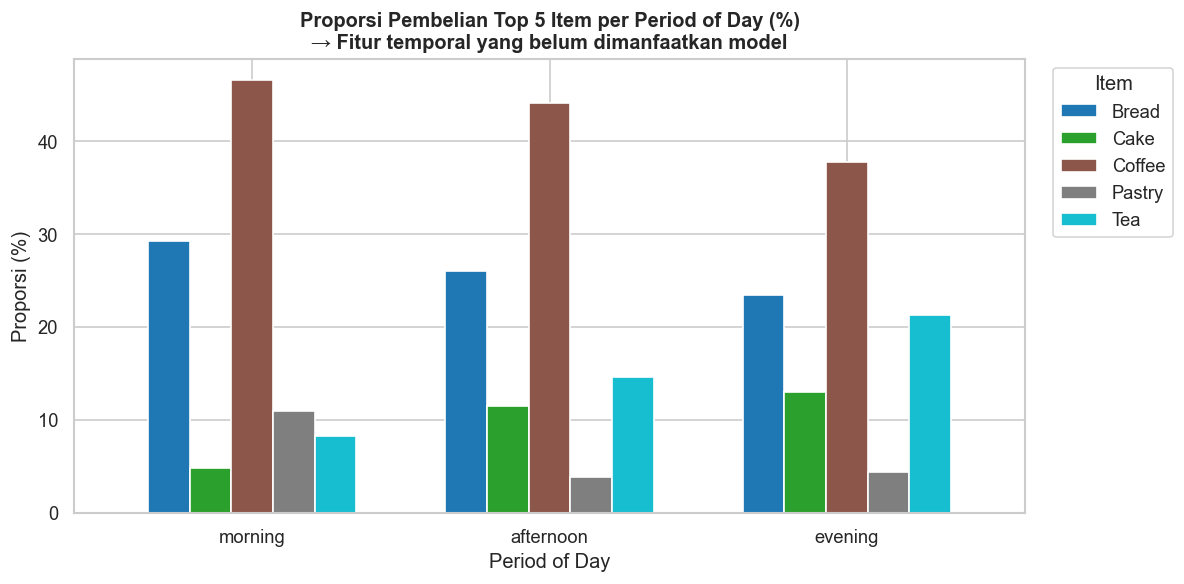

Jika distribusi berbeda antar periode → ada potensi konteks temporal yang bisa dieksploitasi.


In [23]:
# Visualisasi: apakah distribusi pembelian benar-benar berbeda antar periode?
top5 = df['Item'].value_counts().head(5).index
df_top5 = df[df['Item'].isin(top5)]

period_order = [p for p in ['morning', 'afternoon', 'evening', 'night']
                if p in df_top5['period_day'].unique()]

pivot = df_top5.groupby(['period_day', 'Item']).size().unstack(fill_value=0)
pivot = pivot.reindex([p for p in period_order if p in pivot.index])
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100  # normalize per period

pivot_norm.plot(kind='bar', figsize=(10, 5), colormap='tab10', width=0.7)
plt.title('Proporsi Pembelian Top 5 Item per Period of Day (%)\n→ Fitur temporal yang belum dimanfaatkan model', fontsize=12, fontweight='bold')
plt.xlabel('Period of Day')
plt.ylabel('Proporsi (%)')
plt.xticks(rotation=0)
plt.legend(title='Item', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Jika distribusi berbeda antar periode → ada potensi konteks temporal yang bisa dieksploitasi.')

### Kelemahan 5: Cold Start Problem

Model **tidak bisa merekomendasikan** atau **menerima sebagai input** item yang tidak ada dalam 30 item yang dipilih. Jika kafe menambahkan menu baru, model harus di-retrain dari awal — tidak ada mekanisme incremental learning.

### Kelemahan 6: Tidak Ada Personalisasi (User-Agnostic)

Model ini adalah **transaction-based**, bukan **user-based**. Dataset tidak memiliki kolom customer ID, sehingga model tidak bisa belajar preferensi individu pelanggan. Setiap rekomendasi bersifat populasi-level — "orang yang beli X juga sering beli Y" — bukan "kamu secara pribadi sering beli Z".

### Kelemahan 7: K-Sweep Plateau — Bottleneck Arsitektur

Perubahan nilai K (jumlah neighbors) hampir tidak berpengaruh pada performa, menunjukkan bahwa bottleneck **bukan** pada hyperparameter K, melainkan pada arsitektur model itu sendiri.

In [24]:
# K-sweep: uji HR@4 untuk berbagai n_neighbors
k_sweep_results = []

for n_neigh in range(2, 16):
    knn_k = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=n_neigh)
    knn_k.fit(item_transaction_matrix.values)

    # Build temp recommendations
    temp_recs = {}
    for i, item in enumerate(items):
        distances_k, indices_k = knn_k.kneighbors(
            item_transaction_matrix.iloc[i, :].values.reshape(1, -1)
        )
        temp_recs[item] = [
            [items[idx], round(1 - float(d), 6)]
            for idx, d in zip(indices_k.flatten()[1:], distances_k.flatten()[1:])
        ]

    # Evaluate
    h, t = 0, 0
    for tx_id, tx_items in transaksi_valid.items():
        target = tx_items[-1]
        inputs = tx_items[:-1]
        score_map_k = {}
        for inp in inputs:
            if inp in temp_recs:
                for entry in temp_recs[inp]:
                    nb, sc = entry[0], entry[1]
                    if nb not in inputs:
                        score_map_k[nb] = score_map_k.get(nb, 0.0) + sc
        top4 = sorted(score_map_k, key=lambda x: score_map_k[x], reverse=True)[:4]
        if top4:
            t += 1
            h += 1 if target in top4 else 0

    k_sweep_results.append({'n_neighbors': n_neigh, 'HR@4': (h / t * 100) if t > 0 else 0})

ksweep_df = pd.DataFrame(k_sweep_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ksweep_df['n_neighbors'], ksweep_df['HR@4'], marker='o', color='steelblue', linewidth=2)
ax.axhline(ksweep_df['HR@4'].max(), color='red', linestyle='--', alpha=0.5,
           label=f'Max HR@4: {ksweep_df["HR@4"].max():.2f}%')
ax.axhline(ksweep_df['HR@4'].min(), color='orange', linestyle='--', alpha=0.5,
           label=f'Min HR@4: {ksweep_df["HR@4"].min():.2f}%')
ax.set_xlabel('n_neighbors (total, termasuk item itu sendiri)')
ax.set_ylabel('Hit Ratio@4 (%)')
ax.set_title('K-Sweep: Pengaruh n_neighbors terhadap HR@4\n→ Plateau = bottleneck pada arsitektur, bukan hyperparameter')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Range HR@4 selama K-sweep: {ksweep_df["HR@4"].min():.2f}% – {ksweep_df["HR@4"].max():.2f}%')
print(f'Perbedaan max–min         : {ksweep_df["HR@4"].max() - ksweep_df["HR@4"].min():.2f}%')
print()
print('Kesimpulan: Mengubah K tidak signifikan memengaruhi HR@4.')
print('Bottleneck ada pada: (1) single-target evaluation, (2) last-item noise, (3) arsitektur binary KNN.')

IndexError: list index out of range

---
## Ringkasan Kelemahan & Rekomendasi Perbaikan

| # | Kelemahan | Dampak | Solusi Potensial |
|---|-----------|--------|------------------|
| 1 | **Single-target evaluation** | Precision@4 max = 25% secara matematis | Gunakan multi-target evaluation (semua item dalam transaksi yang belum ada di input) |
| 2 | **Last-item sebagai target (noise)** | Ground truth tidak representatif | Leave-one-out (random item), atau full transaction evaluation |
| 3 | **Filter hanya 30 item** | Kehilangan ~64% item dan konteks transaksi | Gunakan semua item, atau filter lebih longgar (top-50, min-freq threshold) |
| 4 | **Fitur temporal tidak digunakan** | Rekomendasi tidak context-aware | Context-Aware Recommendation: pisahkan model per periode |
| 5 | **Cold start** | Menu baru tidak bisa direkomendasikan | Content-based fallback, atau model dengan item embeddings yang updatable |
| 6 | **Tidak ada personalisasi** | Semua pelanggan mendapat rekomendasi sama | Tambahkan customer ID, gunakan matrix factorization atau user-based CF |
| 7 | **K-sweep plateau** | Tuning K tidak membantu | Perbaiki arsitektur: matrix factorization (SVD/ALS), neural collaborative filtering |

---
### Status Produksi
- **`src/train_model.py`** → Script training (simpan `knn_recommendations.json` + `knn_split_metadata.json`)
- **`src/evaluate_model.py`** → Script evaluasi pada validation set
- **`src/main.py`** → FastAPI endpoint `POST /recommend` untuk production serving
- **`models/knn_recommendations.json`** → Model artifact (format: `{item: [[neighbor, similarity_score], ...]}`)